In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import ast

#Data Loading
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [13]:
df.dropna(subset=['salary_year_avg'], inplace=True)
df.head(2)

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",via Ai-Jobs.net,Full-time,False,Costa Rica,2023-08-01 13:37:57,False,False,Costa Rica,year,109500.0,NaN,Netskope,"['gdpr', 'excel']","{'analyst_tools': ['excel'], 'libraries': ['gd..."
77,Data Engineer,Data Engineer,"Arlington, VA",via LinkedIn,Full-time,False,Sudan,2023-06-26 14:22:54,False,False,Sudan,year,140000.0,NaN,Intelletec,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","{'analyst_tools': ['tableau'], 'cloud': ['orac..."


In [7]:
df['job_via'] = df['job_via'].str.replace('via ', '')

In [ ]:
df['job_via'].map({'LinkedIn': 'Linked'}).to_frame()

In [16]:
def salary_category(x):
    if x >= 5000:
        return "High"
    else:
        return "Low"

df["salary_category"] = df["salary_year_avg"].apply(salary_category)

In [54]:
df.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,salary_category
28,Data Scientist,CRM Data Specialist,"San José Province, San José, Costa Rica",Ai-Jobs.net,Full-time,False,Costa Rica,2023/08/01,False,False,Costa Rica,year,109500.0,NaN,Netskope,"['gdpr', 'excel']","{'analyst_tools': ['excel'], 'libraries': ['gd...",High
77,Data Engineer,Data Engineer,"Arlington, VA",LinkedIn,Full-time,False,Sudan,2023/06/26,False,False,Sudan,year,140000.0,NaN,Intelletec,"['mongodb', 'mongodb', 'python', 'r', 'sql', '...","{'analyst_tools': ['tableau'], 'cloud': ['orac...",High
92,Data Engineer,Remote - Data Engineer - Permanent - W2,Anywhere,LinkedIn,Full-time,True,"Illinois, United States",2023/02/21,False,True,United States,year,120000.0,NaN,Apex Systems,"['sql', 'python']","{'programming': ['sql', 'python']}",High
100,Data Scientist,"Data Scientist, Risk Data Mining - USDS","Mountain View, CA",LinkedIn,Full-time,False,"California, United States",2023/07/31,False,True,United States,year,228222.0,NaN,TikTok,"['sql', 'r', 'python', 'express']","{'programming': ['sql', 'r', 'python'], 'webfr...",High
109,Data Analyst,Senior Supply Chain Analytics Analyst,Anywhere,Get.It,Full-time,True,"Illinois, United States",2023/10/12,False,True,United States,year,89000.0,NaN,Get It Recruit - Transportation,"['python', 'r', 'alteryx', 'tableau']","{'analyst_tools': ['alteryx', 'tableau'], 'pro...",High


In [60]:
df.groupby('job_title_short')['search_location'].size().to_frame()

,search_location
job_title_short,
Business Analyst,610
Cloud Engineer,65
Data Analyst,5451
Data Engineer,4500
Data Scientist,5922
Machine Learning Engineer,576
Senior Data Analyst,1131
Senior Data Engineer,1591
Senior Data Scientist,1690


<Axes: title={'center': 'Top 10 Locations for Data Analyst Jobs'}, xlabel='Location', ylabel='Number of Jobs'>

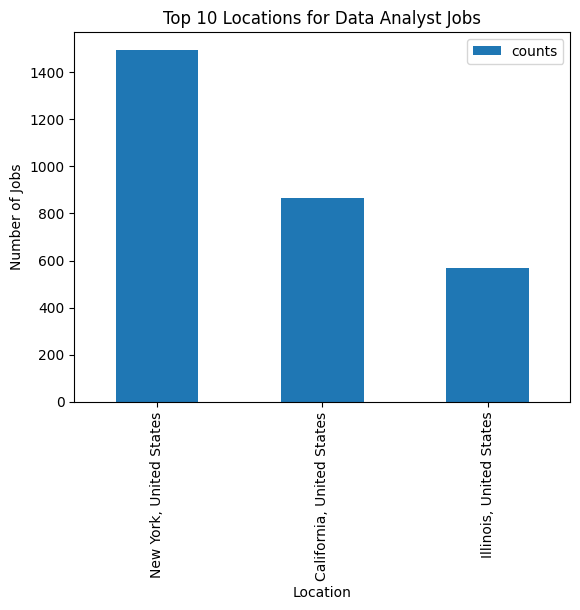

In [63]:
df_grouped = df.groupby(['job_title_short','search_location']).size().reset_index(name='counts').sort_values(by='counts', ascending=False).head(10)
df_grouped[df_grouped['job_title_short'] == 'Data Analyst'].plot.bar(x='search_location', y='counts', title='Top 10 Locations for Data Analyst Jobs', xlabel='Location', ylabel='Number of Jobs')

In [36]:
df.isna().sum()

job_title_short              0
job_title                    0
job_location                 0
job_via                      0
job_schedule_type            0
job_work_from_home           0
search_location              0
job_posted_date              0
job_no_degree_mention        0
job_health_insurance         0
job_country                  0
salary_rate                  0
salary_year_avg              0
salary_hour_avg          22003
company_name                 0
job_skills                   0
job_type_skills              0
salary_category              0
dtype: int64

In [35]:
df['job_skills'].fillna('Unknown', inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_7396\1407194975.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['job_skills'].fillna('Unknown', inplace=True)


In [30]:
df['salary_hour_avg'] = df['salary_hour_avg'].fillna(df['salary_hour_avg'].mean())

In [32]:
df['salary_hour_avg'].mean()

nan